Uses 5,000 provided training images and 1,000 separate test images.

In [2]:
import pandas as pd

train_df = pd.read_csv("fashion-mnist_train.csv").sample(frac=1, random_state=42).head(5000)
test_df = pd.read_csv("fashion-mnist_test.csv").sample(frac=1, random_state=42).head(1000)

In [3]:
train_df.shape, test_df.shape

((5000, 785), (1000, 785))

Separates labels from pixel values in both files.

In [4]:
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

Reshapes the pixels into CNN images and normalizes them to 0–1.

In [5]:
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

Builds the exact CNN architecture required for 10-class image classification.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

n_classes = len(set(y_train))

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(n_classes, activation="softmax")
])

Configures the model for multiclass classification with integer labels.

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Trains the CNN for five complete passes through the training data.

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6597 - loss: 0.9776 - val_accuracy: 0.7070 - val_loss: 0.7546
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7903 - loss: 0.5650 - val_accuracy: 0.7830 - val_loss: 0.5651
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8248 - loss: 0.4819 - val_accuracy: 0.8040 - val_loss: 0.5370
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8397 - loss: 0.4432 - val_accuracy: 0.7940 - val_loss: 0.5774
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8543 - loss: 0.4072 - val_accuracy: 0.8200 - val_loss: 0.4828


Reports the CNN’s accuracy on unseen test images.

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_accuracy

0.8190000057220459

Predicts the clothing class for the first five test images.

In [11]:
predicted_labels = model.predict(X_test[:5], verbose=0).argmax(axis=1)

Displays five test images with their true and predicted clothing labels.

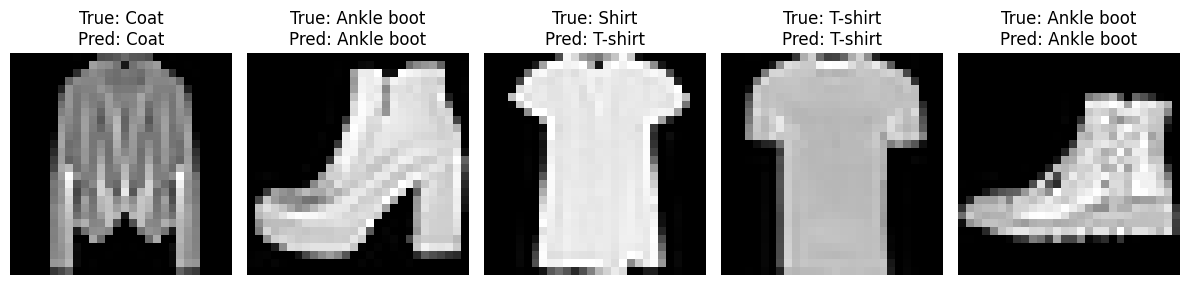

In [12]:
import matplotlib.pyplot as plt

class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title(f"True: {class_names[y_test[i]]}\nPred: {class_names[predicted_labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()